# Regressão Logística
Vamos aplicar os conceitos de regressão logística para o dataset [Breast Cancer](https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset)

In [3]:
from sklearn.datasets import load_breast_cancer
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import sys
from pathlib import Path

root = Path().resolve().parent.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(torch.cuda.is_available())
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

True
Using GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
from functions import Sigmoid
from losses import CrossEntropy

In [5]:
sigmoid = Sigmoid()
cross_entropy = CrossEntropy()

In [6]:
data =  load_breast_cancer()

# Normalizando os dados
X = StandardScaler().fit_transform(data.data)
t = data.target

In [7]:
X_train, X_test, t_train, t_test = \
    train_test_split(X, t, test_size=0.2, random_state=42)

In [8]:
X_train = torch.tensor(X_train, device=device).float()
X_test = torch.tensor(X_test, device=device).float()
t_train = torch.tensor(t_train, device=device).float()
t_test = torch.tensor(t_test, device=device).float()

Vamos inicializar os parâmetros e aplicar o loop de epochs em cima do gradiente da função

In [9]:
theta = torch.zeros(X_train.size()[1], device=device)
one_train = torch.ones_like(t_train, device=device)

In [10]:
# Hiperparâmetros do SGD
batch_size = 256  # Lote menor = updates mais frequentes por época
learning_rate = 5e-4  # Taxa intermediária (5x maior que 1e-4, mas 20x menor que 1e-2)
epochs = 10000  # Muito mais épocas para permitir convergência suave
max_norm = None  # Clipping de gradiente (não estamos usando aqui)

# Target modificado
t_train_new = 2 * t_train - one_train

loss_history = []

for epoch in range(epochs):
    # Iterando sobre os batches
    for start in range(0, X_train.shape[0], batch_size):
        end = start + batch_size
        X_batch = X_train[start:end]
        t_batch = t_train_new[start:end]

        z = t_batch * (X_batch @ theta)
        s = sigmoid.forward( -z )
        v = t_batch * s
        gradient = X_batch.T @ v

        # Aplicar clipping do gradiente (desativado, mas deixamos o código)
        if max_norm is not None:
            gradient_norm = torch.norm(gradient)
            if gradient_norm > max_norm:
                gradient = (gradient / gradient_norm) * max_norm

        theta += learning_rate * gradient

    # Calculando a loss
    y_pred = sigmoid.forward(X_train @ theta)

    loss = cross_entropy.forward(y_pred.unsqueeze(1), t_train_new.unsqueeze(1))
    loss_history.append(loss.item())

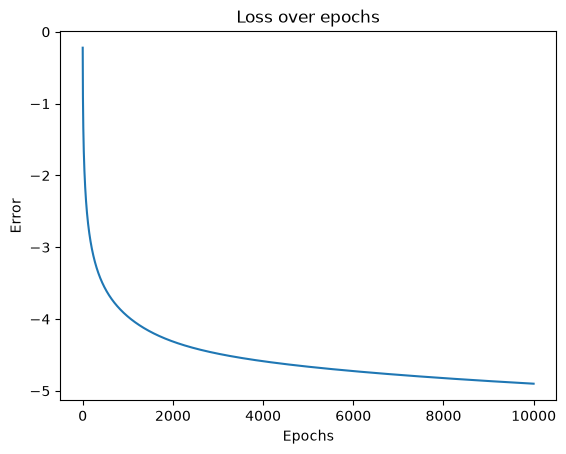

In [11]:
plt.title("Loss over epochs")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.plot(range(len(loss_history)), loss_history)
plt.show()

In [12]:
# Erro dentro do conjunto de testes
y_pred_test = sigmoid.forward(X_test @ theta)

error = cross_entropy.forward(y_pred_test.unsqueeze(1), t_test.unsqueeze(1))

error

tensor(0.0270, device='cuda:0')

In [13]:
# Precision
precision = torch.sum((y_pred_test > 0.5) & (t_test == 1)) / torch.sum(y_pred_test > 0.5)

print(f"Precision: {precision.item():.4f}")

Precision: 0.9857
